<div style="
    text-align:center;
    padding:20px;
    background:linear-gradient(90deg,#020617,#0f172a,#1e293b);
    border-left:3px solid #06b6d4;
    border-radius:10px;
    font-family:'Segoe UI',sans-serif;
">

<h1 style="
    color:#06b6d4;
    font-size:43px;
    margin-bottom:6px;
    font-weight:600;
">
Marketing Campaign Data Pipeline
</h1>

<p style="
    color:#e2e8f0;
    font-size:20px;
    letter-spacing:1px;
    margin-top:0;
">
End-to-End Analysis: Operations, QA & Sales Tracking
</p>

<hr style="
    width:90px;
    border:2px solid #06b6d4;
">

<p style="
    color:#94a3b8;
    font-size:14px;
">
Data Understanding • Cleaning • Exploratory Analysis • Forecasting 
</p>

</div>

---
# Business Understanding

This dataset contains operational, quality assurance, and sales performance records for a marketing campaign.
The dataset contains **26 columns** / **1184 Rows**                                           
The business objectives are:

- Understand campaign performance.
- Identify top-performing agents.
- Evaluate quality assurance impact on sales.
- Analyze conversion performance.
- Forecast future campaign results.

Key business questions:

1. Which agents names , team lead names, closing agents ?
2. which city have more clients?
3. Gender rate?
4. there are many date what the data pattern ? 
5. Does quality score influence conversion?
6. Which products perform best?
7. How is campaign performance changing over time?
8. What can be expected in future periods?

--- 

# import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
from datetime import datetime


 # **phase 1**: Data Understanding & Cleaning


### collection data

In [2]:
dataset = pd.read_csv('../data/sample data.csv', index_col=0)
dataset.head()

,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,State,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
Quality Agent Name,,,,,,,,,,,,,,,,,,,,,
Jude,28-04-2026,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,ME,...,Med Guard Alert,Transferred,Kylie Lopez,Approved,Summer Hudson,21-04-2026,PT Paid today,21-04-2026,21-04-2026,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,IN,...,Med Guard Alert,Transferred,Timothy Williams,Approved,Summer Hudson,22-04-2026,Pt will pay on 05/03/2026\n\nPayment sent to t...,22-04-2026,15-05-2026,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,IA,...,Med Guard Alert,Transferred,Tim ford,Approved,Maeve White,21-04-2026,PT Paid Today,23-04-2026,21-04-2026,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,MI,...,Med Guard Alert,Transferred,Kylie Lopez,Approved,Summer Hudson,21-04-2026,PT Paid today,23-04-2026,21-04-2026,NaN
Victoria,1/5/2026,NaN,NaN,NaN,1/5/2026,NaN,1,NaN,NaN,KS,...,Med Guard Alert,Transferred,Sarah Adams,Approved,Maeve White,22-04-2026,PT Paid Today,22-04-2026,22-04-2026,NaN


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1184 entries, Jude to nan
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Assign Date      192 non-null    object 
 1   Work Duration    148 non-null    float64
 2   Recording link   53 non-null     object 
 3   Validation       149 non-null    object 
 4   Finish Date      152 non-null    object 
 5   QA Feedback      150 non-null    object 
 6   Validated ?      1184 non-null   int64  
 7   Validation Date  149 non-null    object 
 8   Quality Score %  152 non-null    object 
 9   State            1154 non-null   object 
 10  Zip code         1184 non-null   int64  
 11  DOB              1183 non-null   object 
 12  City             1148 non-null   object 
 13  Product          1168 non-null   object 
 14  Gender           1149 non-null   object 
 15  Opener Name      1181 non-null   object 
 16  Client           1183 non-null   object 
 17  Opening Status   

sounds good columns structure but are this all useful?

### general information

In [4]:
print(f"Rows: {dataset.shape[0]}")
print(f"Columns: {dataset.shape[1]}")

Rows: 1184
Columns: 26


In [5]:
dataset.columns.tolist()

['Assign Date',
 'Work Duration',
 'Recording link',
 'Validation',
 'Finish Date',
 'QA Feedback',
 'Validated ?',
 'Validation Date',
 'Quality Score %',
 'State',
 'Zip code',
 'DOB',
 'City',
 'Product',
 'Gender',
 'Opener Name',
 'Client',
 'Opening Status',
 'Team Leader',
 'Closing Status',
 'Closer Name',
 'Date of Sale',
 'Comment',
 'Creation Date',
 'Date of Payment',
 'Pricing List']

In [6]:
dataset.describe()

,Work Duration,Validated ?,Zip code
count,148.000000,1184.000000,1.184000e+03
mean,15.925676,0.125000,4.509291e+05
std,6.819431,0.330859,1.396077e+07
min,6.000000,0.000000,0.000000e+00
25%,10.000000,0.000000,1.427875e+04
50%,15.000000,0.000000,3.956350e+04
75%,20.000000,0.000000,7.280825e+04
max,38.000000,1.000000,4.804242e+08


In [7]:
dataset.describe(include='object')

,Assign Date,Recording link,Validation,Finish Date,QA Feedback,Validation Date,Quality Score %,State,DOB,City,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
count,192,53,149,152,150,149,152,1154,1183,1148,...,1183,1183,1182,1085,1080,551,1147,1183,502,455
unique,5,51,3,6,136,5,34,125,1046,916,...,2,5,18,8,13,39,884,42,58,9
top,29-04-2026,https://drive.google.com/drive/folders/1QPNPHW...,Smooth,29-04-2026,Greeting was pretty good and the agent went st...,29-04-2026,90,CA,2/6/2026,Brooklyn,...,Med Guard Alert,Transferred,Chris Heisenberg,Approved,Summer Hudson,1/6/2026,PT Paid Today,23-04-2026,2/6/2026,$39.95/Month
freq,94,2,107,79,7,77,33,151,10,12,...,841,977,207,387,272,30,77,73,38,154


wow it contain many missing values 

In [8]:
summary = pd.DataFrame({
    "Column":dataset.columns,
    "Data Type":dataset.dtypes.values,
    "Missing":dataset.isnull().sum().values,
    "Missing %":round(dataset.isnull().mean()*100,2).values,
    "Unique Values":dataset.nunique().values
})

summary

,Column,Data Type,Missing,Missing %,Unique Values
0,Assign Date,object,992,83.78,5
1,Work Duration,float64,1036,87.50,27
2,Recording link,object,1131,95.52,51
3,Validation,object,1035,87.42,3
4,Finish Date,object,1032,87.16,6
5,QA Feedback,object,1034,87.33,136
6,Validated ?,int64,0,0.00,2
7,Validation Date,object,1035,87.42,5
8,Quality Score %,object,1032,87.16,34
9,State,object,30,2.53,125


### start pipeline cleaning dataset

#### missing values

In [9]:
print(dataset.isnull().sum())


Assign Date         992
Work Duration      1036
Recording link     1131
Validation         1035
Finish Date        1032
QA Feedback        1034
Validated ?           0
Validation Date    1035
Quality Score %    1032
State                30
Zip code              0
DOB                   1
City                 36
Product              16
Gender               35
Opener Name           3
Client                1
Opening Status        1
Team Leader           2
Closing Status       99
Closer Name         104
Date of Sale        633
Comment              37
Creation Date         1
Date of Payment     682
Pricing List        729
dtype: int64


In [10]:
print(round(dataset.isnull().mean()*100,2))

Assign Date        83.78
Work Duration      87.50
Recording link     95.52
Validation         87.42
Finish Date        87.16
QA Feedback        87.33
Validated ?         0.00
Validation Date    87.42
Quality Score %    87.16
State               2.53
Zip code            0.00
DOB                 0.08
City                3.04
Product             1.35
Gender              2.96
Opener Name         0.25
Client              0.08
Opening Status      0.08
Team Leader         0.17
Closing Status      8.36
Closer Name         8.78
Date of Sale       53.46
Comment             3.12
Creation Date       0.08
Date of Payment    57.60
Pricing List       61.57
dtype: float64


there are a red flag columns have above 90% missing values 
for the any columns have above 30% that can be delete it, and if less that can be fil it with mode or mid 

#### duplicated values

In [11]:
print(dataset.duplicated().sum())

1


In [12]:
dataset[dataset.duplicated()]

,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,State,...,Client,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List
Quality Agent Name,,,,,,,,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NY,...,Med Guard Alert,Transferred,Dona Johnson,Approved,Lilly Williams,6/5/2026,paid on 05/06/2026,6/5/2026,6/5/2026,NaN


one column with duplicated

#### unique values

In [13]:
print(dataset.nunique().sort_values(ascending=False))

Zip code           1048
DOB                1046
City                916
Comment             884
QA Feedback         136
State               125
Opener Name         103
Date of Payment      58
Recording link       51
Creation Date        42
Date of Sale         39
Quality Score %      34
Work Duration        27
Team Leader          18
Closer Name          13
Pricing List          9
Closing Status        8
Finish Date           6
Opening Status        5
Assign Date           5
Validation Date       5
Validation            3
Validated ?           2
Client                2
Product               2
Gender                2
dtype: int64


there are 2 products only   (smartwatch, necklace)                                  
there are 2 client only 
have 916 city                                               
there are 13 closer , 18 team leader!, 103 opener! ,  

#### numerical columns

In [14]:
num_cols = dataset.select_dtypes(
    include=['int64','float64']
).columns

num_cols

Index(['Work Duration', 'Validated ?', 'Zip code'], dtype='object')

In [15]:
dataset[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Work Duration,148.0,15.925676,6.819431e+00,6.0,10.00,15.0,20.00,38.0
Validated ?,1184.0,0.125000,3.308587e-01,0.0,0.00,0.0,0.00,1.0
Zip code,1184.0,450929.122466,1.396077e+07,0.0,14278.75,39563.5,72808.25,480424250.0


In [16]:
dataset[num_cols].skew()

Work Duration     0.900638
Validated ?       2.270665
Zip code         34.409021
dtype: float64

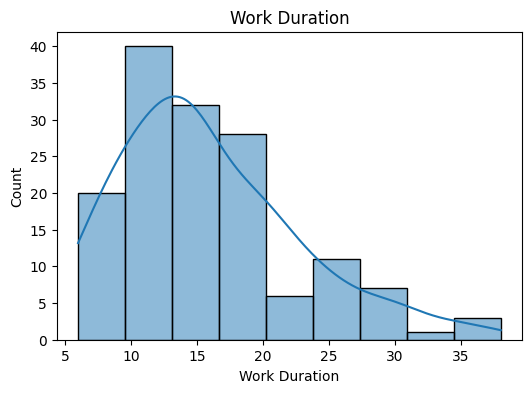

<Figure size 640x480 with 0 Axes>

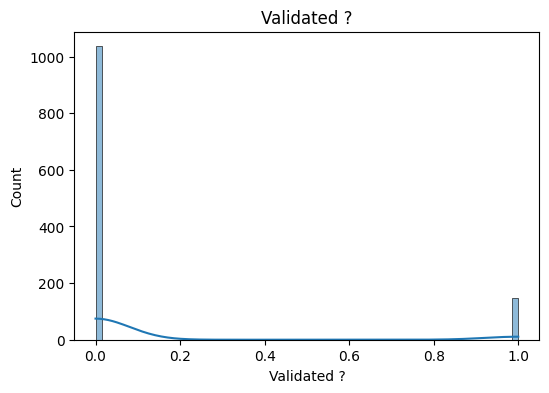

<Figure size 640x480 with 0 Axes>

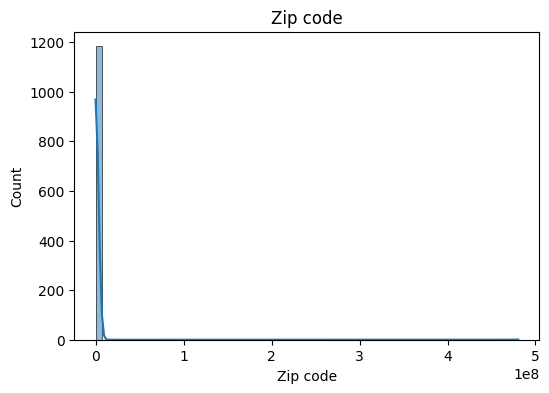

<Figure size 640x480 with 0 Axes>

In [17]:

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot( dataset[col],kde=True)
    plt.title(col)
    plt.show()
    plt.savefig(f'../images/{col}_distribution.png')

outlier detect

In [18]:
print("outliers:")
for col in num_cols:
    Q1 = dataset[col].quantile(.25)
    Q3 = dataset[col].quantile(.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    outliers = dataset[(dataset[col]<lower)|(dataset[col]>upper) ]
    print(col,len(outliers))

outliers:
Work Duration 1
Validated ? 148
Zip code 1


In [19]:
correlation_matrix = dataset[num_cols].corr()
correlation_matrix

,Work Duration,Validated ?,Zip code
Work Duration,1.000000,0.080495,0.067208
Validated ?,0.080495,1.000000,-0.010911
Zip code,0.067208,-0.010911,1.000000


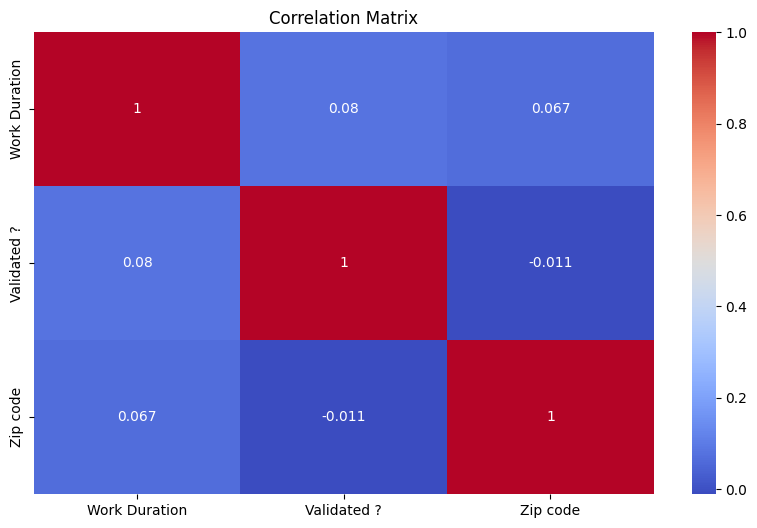

<Figure size 640x480 with 0 Axes>

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()
plt.savefig('../images/correlation_matrix.png')

#### Categorical Analysis

In [21]:
cat_cols = dataset.select_dtypes(
    include='object'
).columns

cat_cols

Index(['Assign Date', 'Recording link', 'Validation', 'Finish Date',
       'QA Feedback', 'Validation Date', 'Quality Score %', 'State', 'DOB',
       'City', 'Product', 'Gender', 'Opener Name', 'Client', 'Opening Status',
       'Team Leader', 'Closing Status', 'Closer Name', 'Date of Sale',
       'Comment', 'Creation Date', 'Date of Payment', 'Pricing List'],
      dtype='object')

In [22]:
print("Categorical Columns and Unique Values:")
for col in cat_cols:
    print(col)
    print(dataset[col].nunique())


Categorical Columns and Unique Values:
Assign Date
5
Recording link
51
Validation
3
Finish Date
6
QA Feedback
136
Validation Date
5
Quality Score %
34
State
125
DOB
1046
City
916
Product
2
Gender
2
Opener Name
103
Client
2
Opening Status
5
Team Leader
18
Closing Status
8
Closer Name
13
Date of Sale
39
Comment
884
Creation Date
42
Date of Payment
58
Pricing List
9


In [23]:
for col in cat_cols:
    print( dataset[col].value_counts().head(10))

Assign Date
29-04-2026    94
28-04-2026    50
30-04-2026    25
1/5/2026      16
4/5/2026       7
Name: count, dtype: int64
Recording link
https://drive.google.com/drive/folders/1QPNPHWn7-Vufjcdhp2UWTKJiS4jQe3nV?usp=drive_link    2
https://drive.google.com/drive/folders/1u3j9mqLJr45d06htv7_DiVDRY6ZBzNqb?usp=drive_link    2
https://drive.google.com/file/d/1f-6ELqGXNGQIugh5I9HSOGtOf8r3One_/view?usp=drive_link      1
https://drive.google.com/drive/folders/1Iaw24v655EFuC8hZaxl__T9Tfeh8OKZ8?usp=drive_link    1
https://drive.google.com/drive/folders/1W1krMJ1_OlQdWGXEJIW0WqHRtDcxXlya?usp=drive_link    1
https://drive.google.com/drive/folders/1Qc_ZT1hl4zhn1sCIKWUnVj9YxGTNs3be?usp=drive_link    1
https://drive.google.com/drive/folders/1HJ1DnJIOpBc_CpG2XGoYQkZd38w34Y_b?usp=drive_link    1
https://drive.google.com/drive/folders/1xC8ldWU5pbhPBBs4oHB6_KjzGPyYYrfu?usp=drive_link    1
https://drive.google.com/file/d/1BcECS6uKCu7uTsuObS3i6T3B6YmvIMT9/view?usp=drive_link      1
https://drive.google.com/

#### Date columns 

In [24]:
date_cols = [
    'Assign Date',
    'Finish Date',
    'Validation Date',
    'Date of Sale',
    'Creation Date',
    'Date of Payment',
    'DOB'
]

In [25]:
for col in date_cols:
    dataset[col] = pd.to_datetime(dataset[col],  errors='coerce')

/tmp/ipykernel_24862/2704931014.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset[col] = pd.to_datetime(dataset[col],  errors='coerce')
/tmp/ipykernel_24862/2704931014.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset[col] = pd.to_datetime(dataset[col],  errors='coerce')
/tmp/ipykernel_24862/2704931014.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset[col] = pd.to_datetime(dataset[col],  errors='coerce')
/tmp/ipykernel_24862/2704931014.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataset[co

In [26]:
for col in date_cols:
    print(col)
    print(dataset[col].min())
    print(dataset[col].max())
    print()

Assign Date
2026-04-28 00:00:00
2026-04-30 00:00:00

Finish Date
2026-01-05 00:00:00
2026-04-05 00:00:00

Validation Date
2026-04-28 00:00:00
2026-04-30 00:00:00

Date of Sale
2026-04-13 00:00:00
2026-05-22 00:00:00

Creation Date
2026-04-13 00:00:00
2026-05-22 00:00:00

Date of Payment
2026-04-13 00:00:00
2026-06-27 00:00:00

DOB
1926-12-03 00:00:00
2026-12-05 00:00:00



In [27]:
(
dataset['Creation Date'].max()
-
dataset['Creation Date'].min()
).days

39

#### process check rate and status

validator status 

In [28]:
dataset["Validated ?"].value_counts()

Validated ?
0    1036
1     148
Name: count, dtype: int64

In [29]:
print(dataset["Validated ?"].mean()*100)

12.5


closing & opening status

In [30]:
dataset["Closing Status"].value_counts()

Closing Status
Approved                 387
Not interested           225
Follow up                172
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [31]:
dataset["Opening Status"].value_counts()

Opening Status
Transferred       977
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Name: count, dtype: int64

Quality score status

In [32]:
print((
    dataset['Quality Score %'].notna().mean()*100
))

12.837837837837837


#### report data quality 

In [33]:
quality_report = pd.DataFrame({

    "Column":dataset.columns,

    "Missing %":
    round(
        dataset.isnull()
        .mean()*100,
        2
    ),

    "Unique Values":
    dataset.nunique(),

    "Data Type":
    dataset.dtypes

})

quality_report

,Column,Missing %,Unique Values,Data Type
Assign Date,Assign Date,85.73,3,datetime64[ns]
Work Duration,Work Duration,87.50,27,float64
Recording link,Recording link,95.52,51,object
Validation,Validation,87.42,3,object
Finish Date,Finish Date,97.97,2,datetime64[ns]
QA Feedback,QA Feedback,87.33,136,object
Validated ?,Validated ?,0.00,2,int64
Validation Date,Validation Date,89.36,3,datetime64[ns]
Quality Score %,Quality Score %,87.16,34,object
State,State,2.53,125,object


### Cleaning Actions
 after review all the dataset columns and rows and cat,num,date columns types i well make this actions:
- let the missing values for QA columns as it not bad data it be the QA Agent not yet reviewed 
- fill customer column with "Unknown" to be not null value
- fill city column with "Unknown" to be not null value  
- fill Gender column with "Unknown" to be not null value
- sales columns: closing status fill with "Not closed" if still active, closer name fill with "Not Assigned"  
-  Date of sales mean there are not a sale for now then not fill them 
-  date of payment means not be pay for now then not fill them 
-  Pricing list fill them with "NAN" there are no sale and extract from it a price in new column 
-  convert all date columns to be the same format and type 
-  for quality score make a map to date and convert them 
-  comments column make a new column from extracting with paid today
-  convert zip code to be cat column this is not a numbers this is a unique ID 
-  Remove the one duplicated rwo it to be the same payment and same product and same date then it not new one for the product and customer 

#### Copy new data frame to be cleaning version

In [34]:
df = dataset.copy()

#### create a red flag for score quality percentage

In [35]:
df['QA Reviewed'] = (
    df['Quality Score %'].notna().astype(int)
)

In [36]:
df.head()

,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,State,...,Opening Status,Team Leader,Closing Status,Closer Name,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List,QA Reviewed
Quality Agent Name,,,,,,,,,,,,,,,,,,,,,
Jude,2026-04-28,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,ME,...,Transferred,Kylie Lopez,Approved,Summer Hudson,2026-04-21,PT Paid today,2026-04-21,2026-04-21,NaN,0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,IN,...,Transferred,Timothy Williams,Approved,Summer Hudson,2026-04-22,Pt will pay on 05/03/2026\n\nPayment sent to t...,2026-04-22,2026-05-15,NaN,0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,IA,...,Transferred,Tim ford,Approved,Maeve White,2026-04-21,PT Paid Today,2026-04-23,2026-04-21,NaN,0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,MI,...,Transferred,Kylie Lopez,Approved,Summer Hudson,2026-04-21,PT Paid today,2026-04-23,2026-04-21,NaN,0
Victoria,NaT,NaN,NaN,NaN,2026-01-05,NaN,1,NaT,NaN,KS,...,Transferred,Sarah Adams,Approved,Maeve White,2026-04-22,PT Paid Today,2026-04-22,2026-04-22,NaN,0


In [37]:
pd.to_numeric(
    df['Quality Score %'],
    errors='coerce'
)

Quality Agent Name
Jude       NaN
NaN        NaN
NaN        NaN
NaN        NaN
Victoria   NaN
            ..
NaN        NaN
NaN        NaN
NaN        NaN
NaN        NaN
NaN        NaN
Name: Quality Score %, Length: 1184, dtype: float64

#### Remove the duplicated row 

In [38]:
df.drop_duplicates(inplace=True)
df.shape

(1183, 27)

#### convert Zip code to categorical

In [39]:
df['Zip code'] = (df['Zip code'].astype(str))

In [40]:
print(df['Zip code'].dtype)

object


#### convert Date columns 

In [41]:
date_cols = [
    'Assign Date',
    'Finish Date',
    'Validation Date',
    'Date of Sale',
    'Creation Date',
    'Date of Payment',
    'DOB'
]

In [42]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col],errors='coerce',dayfirst=True)

#### fill missing values for columns

In [43]:
target_cols_fill = [
    'Client',
    'City',
    'Gender'
]

In [44]:
for col in target_cols_fill:
    df[col]=(df[col].fillna('Unknown').astype(str))


In [45]:
df[target_cols_fill].isnull().sum()

Client    0
City      0
Gender    0
dtype: int64

closing state , closer name 

In [46]:
df['Closing Status'].value_counts()

Closing Status
Approved                 386
Not interested           225
Follow up                172
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [47]:
df['Closing Status'].fillna('Not closed', inplace=True) 

/tmp/ipykernel_24862/3510464189.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Closing Status'].fillna('Not closed', inplace=True)


In [48]:
df['Closing Status'].value_counts()

Closing Status
Approved                 386
Not interested           225
Follow up                172
Not closed                99
Cancelled                 95
Not Eligible              94
Retreansfer to client     47
Pending Bank Approval     37
Postdated                 28
Name: count, dtype: int64

In [49]:
df['Closer Name'].value_counts()

Closer Name
Summer Hudson      272
Lisa Hanz          256
Lilly Williams     231
Maeve White        191
Linda Anderson      45
Marcelle David      36
Jordan Williams     17
kate carter         11
Rose Silva          11
Cole Simmons         4
Louis Mike           2
Adam Steve           2
Lauren Bailey        1
Name: count, dtype: int64

In [50]:
df['Closer Name'].fillna('Not Assigned', inplace=True)

/tmp/ipykernel_24862/3461791041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Closer Name'].fillna('Not Assigned', inplace=True)


In [51]:
df['Closer Name'].value_counts()

Closer Name
Summer Hudson      272
Lisa Hanz          256
Lilly Williams     231
Maeve White        191
Not Assigned       104
Linda Anderson      45
Marcelle David      36
Jordan Williams     17
kate carter         11
Rose Silva          11
Cole Simmons         4
Adam Steve           2
Louis Mike           2
Lauren Bailey        1
Name: count, dtype: int64

Pricing list fill with NAN 

In [52]:
df['Pricing List'].value_counts()

Pricing List
$39.95/Month    154
$49.95/Month    100
$44.95/Month     94
$69.95/Month     44
$59.95/Month     24
$29.95/Month     15
$34.95/Month     12
$64.95/Month     11
$54.95/Month      1
Name: count, dtype: int64

In [53]:
df['Pricing List'].fillna('NAN', inplace=True)

/tmp/ipykernel_24862/3209499846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Pricing List'].fillna('NAN', inplace=True)


In [54]:
df['Pricing List'].value_counts()

Pricing List
NAN             728
$39.95/Month    154
$49.95/Month    100
$44.95/Month     94
$69.95/Month     44
$59.95/Month     24
$29.95/Month     15
$34.95/Month     12
$64.95/Month     11
$54.95/Month      1
Name: count, dtype: int64

Opener name, Team leader fill with Not Assigned

In [55]:
df['Opener Name'].fillna('Not Assigned').astype(str)
df['Team Leader'].fillna('Not Assigned').astype(str)

Quality Agent Name
Jude             Kylie Lopez
NaN         Timothy Williams
NaN                 Tim ford
NaN              Kylie Lopez
Victoria         Sarah Adams
                  ...       
NaN         Chris Heisenberg
NaN         Timothy Williams
NaN             Dona Johnson
NaN         Timothy Williams
NaN              Sarah Adams
Name: Team Leader, Length: 1183, dtype: object

Fill Product with mode

In [56]:
df['Product'].fillna(df['Product'].mode()[0])

Quality Agent Name
Jude           necklace
NaN            necklace
NaN            necklace
NaN         smart watch
Victoria       necklace
               ...     
NaN         smart watch
NaN            necklace
NaN         smart watch
NaN         smart watch
NaN            necklace
Name: Product, Length: 1183, dtype: object

Opening Status fill with Not called

In [57]:
df['Opening Status'].value_counts()

Opening Status
Transferred       976
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Name: count, dtype: int64

In [58]:
df['Opening Status'].fillna('Not called', inplace=True)

/tmp/ipykernel_24862/3481793277.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Opening Status'].fillna('Not called', inplace=True)


In [59]:
df['Opening Status'].value_counts()

Opening Status
Transferred       976
Red Flag          102
Call Back          86
Not Eligible       14
Not interested      4
Not called          1
Name: count, dtype: int64

#### Extract price from column pricing list
- Pricing information was transformed from text format into a numerical monthly price feature for analysis.

In [60]:
df['Monthly Price'] = (df['Pricing List'].astype(str).str.extract(r'(\d+\.\d+)'))

In [61]:
df['Monthly Price'] = pd.to_numeric(df['Monthly Price'],errors='coerce')

In [62]:
df['Monthly Price'].describe()

count    455.000000
mean      47.312637
std       10.042329
min       29.950000
25%       39.950000
50%       44.950000
75%       49.950000
max       69.950000
Name: Monthly Price, dtype: float64

#### create new business Feature 

In [63]:
df['QA Reviewed'] = (df['Quality Score %'].notna().astype(int))

In [64]:
df['Sale Made']= (df['Date of Sale'].notna().astype(int))

In [65]:
df['Payment Received'] = ( df['Date of Payment'].notna().astype(int))

In [66]:
df['Days To Payment'] = (df['Date of Payment'] - df['Date of Sale']).dt.days

In [67]:
df['Days To Payment'] = (df['Days To Payment'].clip(lower=0))

#### Final dataset cleaning

In [68]:
print(df.shape)

df.info()

df.head()

(1183, 31)
<class 'pandas.core.frame.DataFrame'>
Index: 1183 entries, Jude to nan
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Assign Date       169 non-null    datetime64[ns]
 1   Work Duration     148 non-null    float64       
 2   Recording link    53 non-null     object        
 3   Validation        149 non-null    object        
 4   Finish Date       24 non-null     datetime64[ns]
 5   QA Feedback       150 non-null    object        
 6   Validated ?       1183 non-null   int64         
 7   Validation Date   126 non-null    datetime64[ns]
 8   Quality Score %   152 non-null    object        
 9   State             1153 non-null   object        
 10  Zip code          1183 non-null   object        
 11  DOB               519 non-null    datetime64[ns]
 12  City              1183 non-null   object        
 13  Product           1167 non-null   object        
 14  Gender          

,Assign Date,Work Duration,Recording link,Validation,Finish Date,QA Feedback,Validated ?,Validation Date,Quality Score %,State,...,Date of Sale,Comment,Creation Date,Date of Payment,Pricing List,QA Reviewed,Monthly Price,Sale Made,Payment Received,Days To Payment
Quality Agent Name,,,,,,,,,,,,,,,,,,,,,
Jude,2026-04-28,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,ME,...,2026-04-21,PT Paid today,2026-04-21,2026-04-21,NAN,0,NaN,1,1,0.0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,IN,...,2026-04-22,Pt will pay on 05/03/2026\n\nPayment sent to t...,2026-04-22,2026-05-15,NAN,0,NaN,1,1,23.0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,IA,...,2026-04-21,PT Paid Today,2026-04-23,2026-04-21,NAN,0,NaN,1,1,0.0
NaN,NaT,NaN,NaN,NaN,NaT,NaN,0,NaT,NaN,MI,...,2026-04-21,PT Paid today,2026-04-23,2026-04-21,NAN,0,NaN,1,1,0.0
Victoria,NaT,NaN,NaN,NaN,2026-01-05,NaN,1,NaT,NaN,KS,...,2026-04-22,PT Paid Today,2026-04-22,2026-04-22,NAN,0,NaN,1,1,0.0


In [69]:
quality_report = pd.DataFrame({

    'Data Type': df.dtypes,

    'Missing Values': df.isnull().sum(),

    'Missing %':
    round(
        df.isnull().mean()*100,
        2
    ),

    'Unique Values':
    df.nunique()

})

quality_report.sort_values(
    'Missing %',
    ascending=False
)

,Data Type,Missing Values,Missing %,Unique Values
Finish Date,datetime64[ns],1159,97.97,2
Recording link,object,1130,95.52,51
Validation Date,datetime64[ns],1057,89.35,3
Work Duration,float64,1035,87.49,27
Validation,object,1034,87.40,3
QA Feedback,object,1033,87.32,136
Quality Score %,object,1031,87.15,34
Assign Date,datetime64[ns],1014,85.71,3
Days To Payment,float64,941,79.54,19
Date of Payment,datetime64[ns],919,77.68,33


#### Save the clean data 

In [71]:
df.to_csv('../data/data cleaned.csv', index=False, encoding='utf-8-sig')

#

---
This dataset appears to represent a lead management and sales funnel process for a healthcare related marketing campaign. Leads are initially created and assigned to sales representatives (Openers), potentially transferred to Closers for final conversion, then reviewed by the Quality Assurance team. The analysis will focus on understanding sales performance, conversion behavior, quality assurance outcomes, and operational efficiency across agents and teams.

--- 
Lead Creation                                                                   
      ↓                                                                                         
Lead Assignment                                                             
      ↓                                                                                 
Sales Activity                                                      
      ↓                                                                             
Quality Assurance Review                                                                        
      ↓                                                                             
Validation                                              
      ↓                                                                     
Sale Closure                                                                                    
      ↓                                                                             
Payment Collection                                                  


# **Phase 2**: Exploratory Data Analysis & Visualization

# **Phase 3**: Time-Series Analysis & Forecasting


# **Phase 4**: Business Insights & Takeaways

The following three takeaways are directly evidenced by the data and are the ones surfaced in the README and dashboard.

#


<head>
    <title>Team Credits</title>
    <style>
        body {
            font-family: Arial, sans-serif;
            background-color:rgba(23, 20, 20, 0.74);
            margin: 0;
            padding: 0;
            display: flex;
            justify-content: center;
            align-items: center;
            min-height: 100vh;
        }
        .container {
            text-align: center;
            background-color:rgb(26, 72, 101);
            padding: 40px;
            border-radius: 10px;
            box-shadow: 0 4px 8px rgba(0, 0, 0, 0.1);
            max-width: 1100px;
            width: 100%;
        }
        h1 {
            color: #000000;
            font-size: 2.5em;
            margin-bottom: 10px;
        }
        h3 {
            color: #000000;
            font-size: 1.5em;
            margin: 20px 0;
        }
        ul {
            list-style: none;
            padding: 0;
            margin: 20px 0;
        }
        ul li {
            font-size: 1.2em;
            margin: 10px 0;
        }
        ul li a {
            color: #000000;
            text-decoration: none;
            transition: color 0.3s;
        }
        ul li a:hover {
            color: #007bff;
        }
        .github-section {
            margin-top: 30px;
        }
        .github-section p {
            color: #000000;
            font-size: 1.1em;
            margin-bottom: 10px;
        }
        .github-section a img {
            width: 50px;
            height: 50px;
            transition: transform 0.3s;
        }
        .github-section a img:hover {
            transform: scale(1.1);
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>Thank You for Your Time and Efforts</h1>
        <h3>This Work Done By ENG</h3>
        <ul>
            <li><a href="https://github.com/youssef-113" target="_blank">Youssef Bassiony Abdallah</a></li>
        </ul>
        <div class="github-section">
            <p>For GitHub Repository</p>
            <a href="https://github.com/youssef-113/end-to-end-TimeSeries-forecasting" title="Redirect to GitHub" target="_blank">
                <img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" alt="GitHub">
            </a>
        </div>

</body>
